# Assignment 1: Evaluating Language Technologies
This assignment must be completed in order to be considered for enrollment in the class. If you are already enrolled, failure to complete this assignment will result in your removal from the course.

## Introduction
In this assignment, we will explore different tasks core to the field of NLP. You will implement different evaluation metrics for these tasks and perform analysis of different language
technologies.

Learning objectives:
* Understand the breadth of tasks core to the field of NLP.
* Implement various evaluation methods for core NLP tasks.
* Become familiar with prompting existing LLMs via API calls.
* Identify the limitations of automatic evaluation methods.
* Practice using error analysis to identify where language technologies fail and hypothesizing why they might fail.
* Appreciate things we humans do with language that current language models cannot do.

**Notes:**
* In your solution, keep all code as-is except where it's explicitly mentioned to implement a function.
* Items marked with a star (★) should be answered in markdown text in the notebook. You will include your final notebook as a pdf with your submission.
* Results are written to the `results/` sub-directory as you go, and these are what get autograded.

**Submission:**

When you are done, run `python3 make_submission.py`. It checks that every file the
notebook should have written is present, valid, and actually filled in, then packs
them into `submission.zip` for you to upload to gradescope. Two things go in it:

* All the json files saved inside the `results/` directory. These will be autograded.
* A PDF copy of your completed notebook, titled "HW1.pdf". This is used to grade your answers to the problems marked with a (★), so check that your plots rendered before exporting.

**Setup:**
You will need to download ollama https://ollama.com and install the following models with the commands:

`ollama pull qwen3:8b`

`ollama pull llama3.2:1b`

`ollama pull llama3.2`

`ollama pull gemma3:1b`

`ollama pull gemma3:4b`

You will need about 13GB of storage to download these models. Make sure the ollama binary is in /usr/local/bin/ or you know where it is, so you can call it on the command line.

## Running on Google Colab

Set **Runtime → Change runtime type → GPU**, then run the cell below once. It
clones the repo, installs everything, points your inference cache at Drive so a
disconnect can't throw away work, and starts ollama.

Running on your own machine instead? The cell does nothing — follow the README.

In [2]:
# Colab setup. On a local machine this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    import os, subprocess, time

    STUDENT_REPO = "https://github.com/zinengtang/cs183-fall26-a1.git"
    DRIVE_DIR = "/content/drive/MyDrive/cs183-a1"

    # 1. code and data, since opening a notebook from GitHub brings only the notebook
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", STUDENT_REPO, "/content/repo"], check=True)
    os.chdir("/content/repo")

    # 2. dependencies (ffmpeg is already on Colab). Capture rather than -q: a bare
    #    CalledProcessError tells you nothing about which package refused to install.
    installed = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
                               capture_output=True, text=True)
    if installed.returncode != 0:
        print(installed.stdout[-2000:])
        print(installed.stderr[-2000:])
        raise RuntimeError("pip install failed -- see the output above for which package and why")

    # 3. keep generations and results on Drive -- the runtime's own disk does not
    #    survive a disconnect, and re-running inference costs far more than this does
    from google.colab import drive
    drive.mount("/content/drive")
    for sub in ("inference_cache", "results"):
        os.makedirs(f"{DRIVE_DIR}/{sub}", exist_ok=True)
        subprocess.run(["rm", "-rf", sub], check=True)
        os.symlink(f"{DRIVE_DIR}/{sub}", sub)

    # 4. ollama. Colab has no systemd, so the installer cannot start the server for us.
    #    Only the four small models are pulled here. The 5.2GB judge model that Part 4
    #    needs is pulled at Part 4, so Parts 1-3 are not stuck behind that download.
    #    The installer unpacks a .tar.zst and exits with an error if zstd is missing,
    #    which it is on Colab. There is no .tgz build to fall back to any more.
    if subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"]).returncode != 0:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], check=True)

    installer = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                               shell=True, capture_output=True, text=True)
    if installer.returncode != 0:
        print(installer.stdout[-2000:])
        print(installer.stderr[-2000:])
        raise RuntimeError("the ollama installer failed, see the output above for why")

    subprocess.Popen(["ollama", "serve"])
    time.sleep(5)
    for model in ["llama3.2:1b", "llama3.2", "gemma3:1b", "gemma3:4b"]:
        print(f"pulling {model}")
        subprocess.run(["ollama", "pull", model], check=True)

    print("\nReady. Run the rest of the notebook from the top.")
else:
    print("Not on Colab -- see the README for local setup.")

Mounted at /content/drive
pulling llama3.2:1b
pulling llama3.2
pulling gemma3:1b
pulling gemma3:4b

Ready. Run the rest of the notebook from the top.


## Part 0: Setup

In [3]:
import pandas as pd
from pandas.core.frame import DataFrame
import aiohttp
import asyncio
import json
from tqdm import tqdm
from typing import Dict
import os

# ollama serves requests from a small queue, so firing hundreds at once just builds a
# backlog that runs past aiohttp's 5 minute default timeout. Bound both explicitly.
MAX_CONCURRENT_REQUESTS = 8
REQUEST_TIMEOUT_SECONDS = 600


class OllamaError(RuntimeError):
    pass


def save_results(results, filename):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)

async def run_inference(model_name, prompt, temperature=0.0, max_tokens=16, session=None):
    """
    curl http://localhost:11434/api/generate -d '{
		"model": "llama3.2",
		"prompt":"Why is the sky blue?",
		"stream": false,
	}'
    """
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        # Reasoning models spend their whole token budget thinking before they answer,
        # which for a 16-token judge call means an empty response. Models without a
        # thinking mode ignore this.
        "think": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        },
    }

    async def _post(open_session):
        async with open_session.post("http://localhost:11434/api/generate", json=payload) as response:
            if response.status != 200:
                # e.g. a model that has not been pulled yet answers 404 with an error
                # payload, whose .get("response", "") is an empty string -- silently
                # caching those looks exactly like a model that scores zero.
                raise OllamaError(f"ollama returned {response.status}: {(await response.text())[:200]}")
            result = await response.json()
            if "error" in result:
                raise OllamaError(result["error"])
            return result.get("response", "")

    if session is not None:
        return await _post(session)
    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as new_session:
        return await _post(new_session)

async def run_batch_inference(model_name, prompts, temperature=0.0, max_tokens=16):
    progress = tqdm(total=len(prompts))
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    failures = []

    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as session:
        async def _run_inference(prompt):
            async with semaphore:
                try:
                    result = await run_inference(model_name, prompt, temperature, max_tokens, session=session)
                except Exception as e:
                    # returning None instead of raising keeps one bad request from
                    # discarding every other result in the batch
                    failures.append(f"{type(e).__name__}: {e}")
                    result = None
                progress.update(1)
                return result
        results = await asyncio.gather(*[_run_inference(prompt) for prompt in prompts])

    if failures:
        print(f"{len(failures)}/{len(prompts)} requests to {model_name} failed and were not cached; "
              f"re-run this cell to retry them. First failure: {failures[0]}")
    return results

def cache_inferences(model_name, exp_name, prompts, inferences):
    # skip failed requests so they are retried rather than cached as missing answers
    fresh = {prompt: inference for prompt, inference in zip(prompts, inferences) if inference is not None}
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            cache.update(fresh)
    else:
        cache = fresh
    with open(f"inference_cache/{model_name}_{exp_name}.json", "w") as f:
        json.dump(cache, f)

def load_inferences(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [cache[prompt] if prompt in cache else None for prompt in prompts]
    return [None for _ in prompts]

def get_remaining_prompts(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [prompt for prompt in prompts if prompt not in cache]
    return prompts

models = [
    "llama3.2:1b" ,
    "llama3.2",
    "gemma3:1b",
    "gemma3:4b",
]

## Part 1: Text classification (25 points)
Here, we will evaluate different LLMs on their ability to perform newsgroup classification. You will implement four standard metrics for evaluating a classifier and create a visualization of the errors using a confusion matrix. We will be using a classic NLP dataset, 20 Newsgroups (http://qwone.com/~jason/20Newsgroups/).

### Part 1.0: Setup
Load the data we will be using for evaluation. This is the development set of the dataset, so it's ok for us to do analysis with it.

We will load the possible labels from the training set, rather than the development set. If a new label has to be predicted at test-time, we wouldn't have learned it from training only on the training set!

In [10]:
classification_inputs = pd.read_csv('A1_Data/dev_data.csv')
classification_labels = pd.read_csv('A1_Data/dev_labels.csv')
classification_data = pd.merge(classification_inputs, classification_labels, on="id", how="inner")[:200]

print(f"Loaded newsgroup data of shape {classification_data.shape} with columns {classification_data.columns.tolist()}.")

labels = pd.read_csv('A1_Data/train_labels.csv')["newsgroup"].unique()
label_list = ", ".join(sorted(list(labels)))

print(f"Found {len(labels)} possible target labels: ")
print(label_list)


def normalize_prediction(text):
	"""Clean a raw model response up so it can be compared against a label.

	Model output is not guaranteed to be exactly one of the newsgroup names.
	Responses here routinely carry a trailing newline, and a model that ignores
	the "no other text" instruction may wrap the label in something longer.
	Deciding how to read a model's answer is part of the evaluation, not a
	detail -- for one of these models, skipping this step more than halves its
	measured accuracy.
	"""
	if text is None:
		# the request failed and was not cached -- re-run the inference cell to retry it
		return ""
	return text.strip()

Loaded newsgroup data of shape (200, 3) with columns ['id', 'text', 'newsgroup'].
Found 20 possible target labels: 
alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc


Now let's run inference with the different classifiers. It will take some time to run inference.

If you cannot get ollama running, `inference_cache_reference/` holds our own generations for Parts 1, 3 and 4.0 — copy them into `inference_cache/` and the cells below will use those. Say so in your writeup if you do, and note that Part 4's judge is not cached, so 4.1, 4.2 and 4.4 need a working ollama regardless.

In [11]:
def get_newsgroup_prompt(text):
	newsgroup_prompt = "In which of the following newsgroups is the following email most likely to appear? Output only the newsgroup name, no other text."
	newsgroup_prompt += f"\n\nNewsgroups:\n{label_list}\n\nEmail:\n{text}"
	return newsgroup_prompt

prompts = [get_newsgroup_prompt(text) for text in classification_data["text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt1_0_classification_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=16)
	cache_inferences(model, "pt1_0_classification_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt1_0_classification_data", prompts)
	classification_data[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


100%|██████████| 7/7 [00:08<00:00,  1.27s/it]


Running inference for gemma3:4b


100%|██████████| 21/21 [00:27<00:00,  1.30s/it]


In [12]:
classification_data

,id,text,newsgroup,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,From: tim@kimba.catt.citri.edu.au (Tim Liddelo...,comp.windows.x,talk.politics.misc,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
1,1,From: petrack@vnet.IBM.COM\nSubject: disabling...,comp.sys.mac.hardware,talk.politics.misc,talk.politics.misc,alt.atheism\n,comp.os.ms-windows.misc\n
2,2,From: Lars.Jorgensen@p7.syntax.bbs.bad.se (Lar...,comp.graphics,talk.politics.misc,talk.religion.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
3,3,From: dnh@mfltd.co.uk (Des Herriott)\nSubject:...,comp.windows.x,talk.politics.misc,talk.politics.misc,rec.motorcycles,comp.os.ms-windows.misc\n
4,4,From: willisw@willisw.ENG.CLEMSON.edu (Bill Wi...,comp.sys.ibm.pc.hardware,talk.politics.guns,talk.religion.misc,alt.comp.graphics\n,comp.os.ms-windows.misc\n
...,...,...,...,...,...,...,...
195,195,From: fox@graphics.cs.nyu.edu (David Fox)\nSub...,soc.religion.christian,talk.politics.misc,alt.atheism,rec.motorscycles,alt.atheism\n
196,196,From: moor9881@mach1.wlu.ca (Dwayne Moore u)\n...,comp.os.ms-windows.misc,talk.politics.misc,comp.sys.ibm.pc.hardware,rec.autos\n,comp.os.ms-windows.misc\n
197,197,From: nsmca@aurora.alaska.edu\nSubject: Re: ar...,sci.space,sci.electronics,talk.politics.military,rec.motorscycles,talk.politics.guns\n
198,198,From: ohayon@jcpltyo.JCPL.CO.JP (Tsiel Ohayon)...,talk.politics.mideast,talk.politics.guns,talk.politics.misc,rec.sport\n,talk.politics.mideast\n


### Part 1.1: Confusion Matrix (5 points)
Complete the following functions. The first one should computes a confusion matrix for a set of predictions, and the second one should use your favorite tool (e.g. Matplotlib) to visualize it as a heatmap.

We're implementing the confusion matrix first because you might find it useful when completing the rest of Part 1.

If the model messes up the output format (e.g. outputs something that isn't one of the labels), the prediction should not be included in the matrix counts.

In [13]:
for model in models:
    col = f"predictions_{model}"
    print(model, "missing:", classification_data[col].isna().sum())

llama3.2:1b missing: 0
llama3.2 missing: 0
gemma3:1b missing: 0
gemma3:4b missing: 0


In [14]:
def part1_1_cm(x: DataFrame, y: str) -> Dict[str, Dict[str, int]]:
    label_names = sorted(labels)

    # rows = true labels, columns = predicted labels
    cm = {
        true_label: {pred_label: 0 for pred_label in label_names}
        for true_label in label_names
    }

    prediction_col = f"predictions_{y}"

    for _, row in x.iterrows():
        true_label = row["newsgroup"]
        pred_label = normalize_prediction(row[prediction_col])

        # Assignment says invalid model outputs should be excluded
        # from the confusion matrix.
        if pred_label in label_names:
            cm[true_label][pred_label] += 1

    return cm


def part_1_1_vis(x: Dict[str, Dict[str, int]]):
    import matplotlib.pyplot as plt
    import numpy as np

    label_names = sorted(x.keys())

    matrix = np.array([
        [x[true_label][pred_label] for pred_label in label_names]
        for true_label in label_names
    ])

    fig, ax = plt.subplots(figsize=(12, 10))
    image = ax.imshow(matrix)

    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))

    ax.set_xticklabels(label_names, rotation=90)
    ax.set_yticklabels(label_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()

Now we'll use these functions to compute and visualize confusion matrices for each classifier.

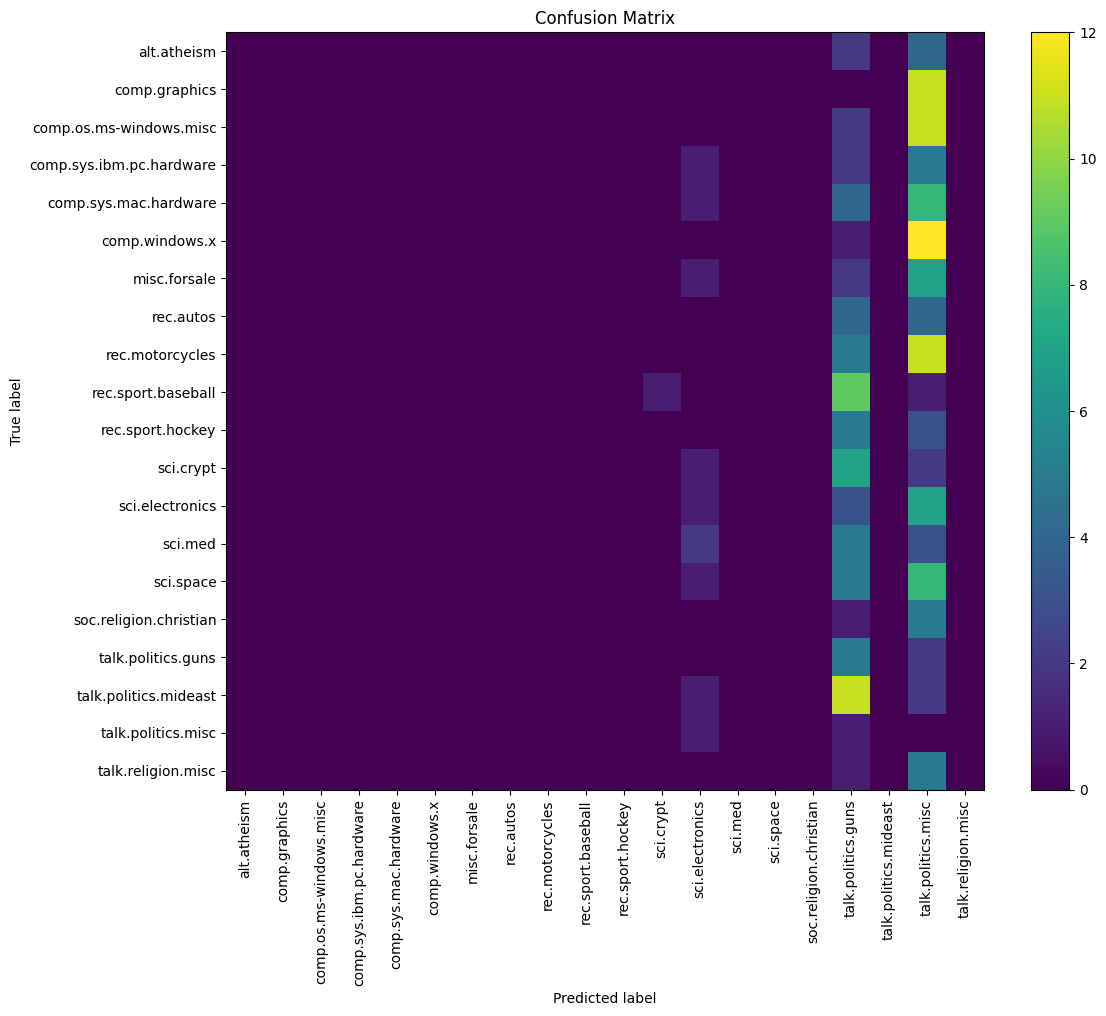

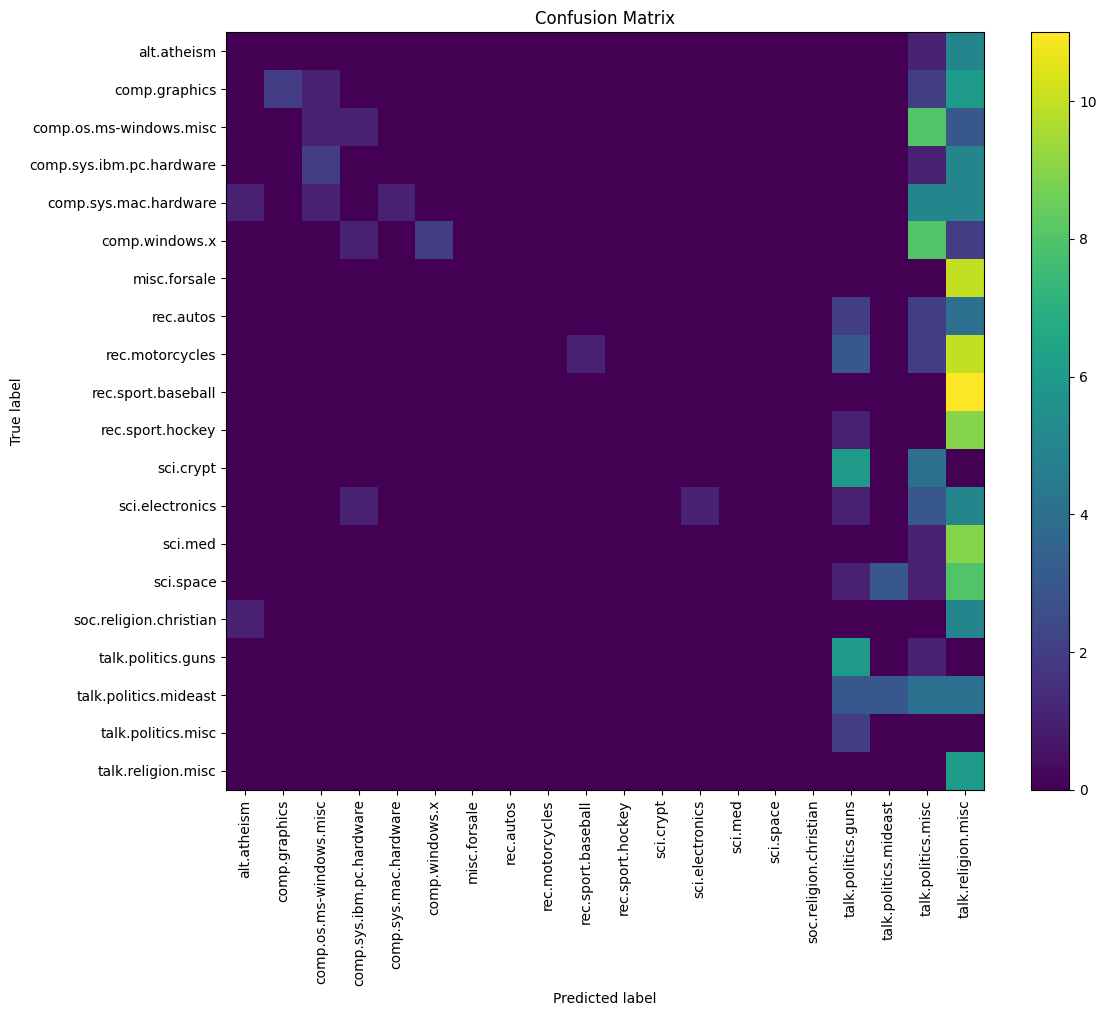

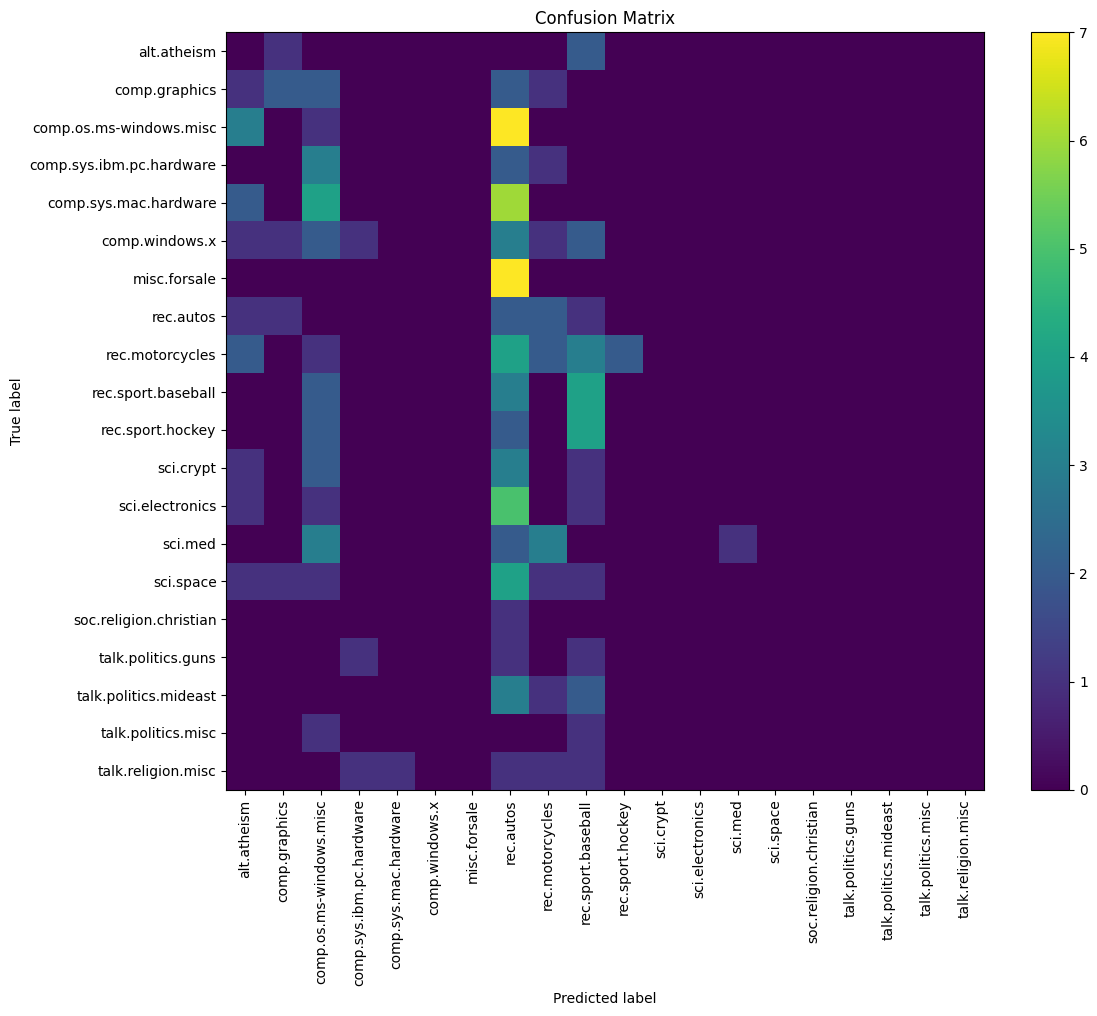

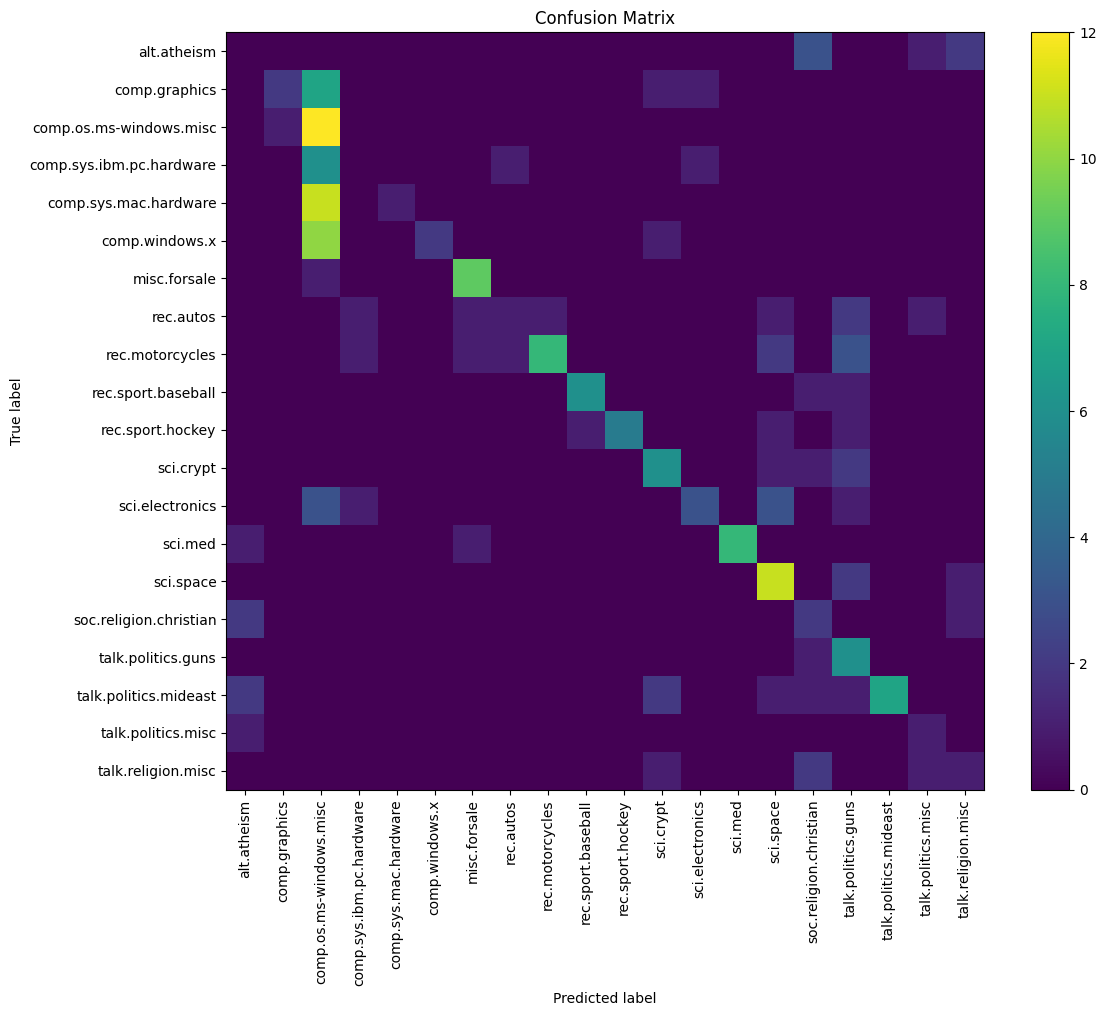

In [15]:
confusion_matrices = dict()

for model in models:
    confusion_matrices[model] = part1_1_cm(classification_data, model)
    part_1_1_vis(confusion_matrices[model])

★ Make sure the images are rendered in the notebook pdf you submit.

★ For each of the different classifiers, which pair of classes is most often confused?

★ Use the scratch space below to explore the documents that are misclassified most often with these class pairings, and include snippets of a few examples below.

★ Why might these pairs of classes be more difficult for the classifiers to distinguish?

In [18]:
# TODO: Use this scratch space to find documents
# that are examples of common misclassifications
def most_confused_pair(cm):
    label_names = sorted(cm.keys())

    best_pair = None
    highest_count = -1

    for i in range(len(label_names)):
        for j in range(i + 1, len(label_names)):
            a = label_names[i]
            b = label_names[j]

            # Count confusion in both directions:
            # true A predicted B + true B predicted A
            count = cm[a][b] + cm[b][a]

            if count > highest_count:
                highest_count = count
                best_pair = (a, b)

    return best_pair, highest_count


for model in models:
    pair, count = most_confused_pair(confusion_matrices[model])
    print(model, ":", pair, "count =", count)
    class_a, class_b = pair
    pred_col = f"predictions_{model}"

    examples = classification_data[
        (
            (classification_data["newsgroup"] == class_a) &
            (classification_data[pred_col].apply(normalize_prediction) == class_b)
        )
        |
        (
            (classification_data["newsgroup"] == class_b) &
            (classification_data[pred_col].apply(normalize_prediction) == class_a)
        )
    ]

    print("\n==========================")
    print("MODEL:", model)
    print("PAIR:", class_a, "<->", class_b)

    for _, row in examples.head(3).iterrows():
        print("\nTRUE:", row["newsgroup"])
        print("PREDICTED:", normalize_prediction(row[pred_col]))
        print("TEXT:", row["text"][:400])

llama3.2:1b : ('comp.windows.x', 'talk.politics.misc') count = 12

MODEL: llama3.2:1b
PAIR: comp.windows.x <-> talk.politics.misc

TRUE: comp.windows.x
PREDICTED: talk.politics.misc
TEXT: From: tim@kimba.catt.citri.edu.au (Tim Liddelow)
Subject: Installing MIT X11R5 on Apollo
Organization: CATT Centre at CITRI, Melbourne, Australia
Lines: 14

Can any Apollo GURUS out there let me know of their experiences building MIT X11R5,
with or without GCC 2.3.3.  In particular, is there anything I should watch out for.

Thanks in advance

--tim 
_______________________________________________

TRUE: comp.windows.x
PREDICTED: talk.politics.misc
TEXT: From: dnh@mfltd.co.uk (Des Herriott)
Subject: XDM/xsession woes
Keywords: xdm, xterm
Lines: 22
Reply-To: dnh@mfltd.co.uk
Organization: Micro Focus Ltd.
X-Newsreader: mxrn 6.18-3


I've just managed to get xdm running from an NCR 3000 (an SVR4 486 box
running XFree86 1.2) to my NCD XDisplay.  It's pretty much working, but
I'm encountering a weird error



**Most commonly confused class pairs**

- `llama3.2:1b`: `comp.windows.x` and `talk.politics.misc` — 12 total confusions.
- `llama3.2`: `rec.sport.baseball` and `talk.religion.misc` — 11 total confusions.
- `gemma3:1b`: `comp.os.ms-windows.misc` and `rec.autos` — 7 total confusions.
- `gemma3:4b`: `comp.os.ms-windows.misc` and `comp.sys.mac.hardware` — 11 total confusions.

For `llama3.2:1b`, several `comp.windows.x` posts about X11, XDM, xterm, and C++ GUI tools were incorrectly predicted as `talk.politics.misc`. These examples do not actually have much political content, suggesting that the small 1B model is not separating topics reliably and may be over-predicting a small number of classes.

For `llama3.2`, several baseball posts, including MLB scores, Nolan Ryan's injury, and discussion of the 1964 Phillies, were classified as `talk.religion.misc`. Again, there is little semantic overlap, so this confusion seems more like weak classification ability than genuine ambiguity between the categories.

For `gemma3:1b`, Windows-related posts discussing graphics benchmarks, Windows 3.1, DOS, and video-card drivers were predicted as `rec.autos`. These categories are not closely related, indicating that the 1B model is likely relying on weak lexical cues rather than accurately recognizing the overall topic.

The `gemma3:4b` confusion is more understandable. It often confuses `comp.os.ms-windows.misc` with `comp.sys.mac.hardware`. Both categories contain discussions of computers, displays, graphics hardware, drivers, power management, and peripherals. Because these categories share substantial technical vocabulary, distinguishing the operating-system-specific context can be difficult.

### Part 1.2: Accuracy (5 points)
Complete the following function, then use it to compute and compare the accuracies of each classifier.

Model predictions are raw text, not clean labels. Pass each one through
`normalize_prediction` (defined in Part 1.0) before comparing it to the ground
truth, and do it consistently across Parts 1.1 through 1.5 -- comparing the raw
strings scores at least one of these models far below its real accuracy.

A prediction that is still not one of the labels after normalising counts as
incorrect in Parts 1.2 through 1.5. Part 1.1 is the exception: a confusion
matrix has no cell to put it in, so it is left out of the counts there.

★ Generate a table comparing the accuracy of each of the classifier systems.

★ Which one has the highest accuracy?

In [20]:
def part1_2_acc(x: DataFrame, y: str) -> float:
    prediction_col = f"predictions_{y}"
    correct = 0

    for _, row in x.iterrows():
        prediction = normalize_prediction(row[prediction_col])
        true_label = row["newsgroup"]

        if prediction == true_label:
            correct += 1

    return correct / len(x)


accuracies: dict[str, float] = dict()

for model in models:
    accuracies[model] = part1_2_acc(classification_data, model)

save_results(accuracies, "results/accuracies.json")

best_model = max(accuracies, key=accuracies.get)

accuracy_table = pd.DataFrame({
    "Model": list(accuracies.keys()),
    "Accuracy": list(accuracies.values())
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("Best model:", best_model)
print("Best accuracy:", accuracies[best_model])

accuracy_table

Best model: gemma3:4b
Best accuracy: 0.455


,Model,Accuracy
0,gemma3:4b,0.455
1,llama3.2,0.110
2,gemma3:1b,0.060
3,llama3.2:1b,0.030


`gemma3:4b` has the highest accuracy at 0.455 (45.5%). It performs substantially better than the other classifiers. `llama3.2` achieves 11.0% accuracy, `gemma3:1b` achieves 6.0%, and `llama3.2:1b` achieves 3.0%.

### Part 1.3: Precision (5 points)
Complete the following function that returns, for each class, the precision of the classifier's labels given ground-truth labels. (note: if there are no predictions for a given class, then precision should be 0)

★ Generate a table showing, for the best-performing classifier, the precision of its labels across each class.

★ For which class are its labels the most accurate? The least?

In [23]:
def part1_3_prec(x: DataFrame, y: str) -> dict[str, float]:
    prediction_col = f"predictions_{y}"
    precisions = {}

    for label in labels:
        true_positive = 0
        predicted_positive = 0

        for _, row in x.iterrows():
            prediction = normalize_prediction(row[prediction_col])
            true_label = row["newsgroup"]

            if prediction == label:
                predicted_positive += 1

                if true_label == label:
                    true_positive += 1

        if predicted_positive == 0:
            precisions[label] = 0.0
        else:
            precisions[label] = true_positive / predicted_positive

    return precisions


if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_prec = None
else:
    best_model_prec = part1_3_prec(classification_data, best_model)

save_results(best_model_prec, "results/best_model_prec.json")

precision_table = pd.DataFrame({
    "Class": list(best_model_prec.keys()),
    "Precision": list(best_model_prec.values())
}).sort_values("Precision", ascending=False).reset_index(drop=True)

precision_table



,Class,Precision
0,sci.med,1.000000
1,comp.windows.x,1.000000
2,comp.sys.mac.hardware,1.000000
3,talk.politics.mideast,1.000000
4,rec.sport.hockey,1.000000
5,rec.motorcycles,0.888889
6,rec.sport.baseball,0.857143
7,misc.forsale,0.750000
8,comp.graphics,0.666667
9,sci.electronics,0.600000


For `gemma3:4b`, the highest precision is 1.0. Five classes achieve perfect precision: `sci.med`, `comp.windows.x`, `comp.sys.mac.hardware`, `talk.politics.mideast`, and `rec.sport.hockey`. This means that every time the model predicted one of these classes in this evaluation set, the prediction was correct.

The lowest precision is 0.0 for `comp.sys.ibm.pc.hardware` and `alt.atheism`. The model did not make any correct predictions among the examples it assigned to these classes. Overall, the precision values vary substantially across categories, showing that even though `gemma3:4b` is the best classifier by accuracy, its reliability still depends strongly on which class it predicts.

### Part 1.4: Recall (5 points)
Complete the following function that returns, for each target class, the recall of the classifier's labels. (note: if there are no ground truth labels for a given class, the recall should be 0)

★ Generate a table showing, for each target class, the recall of the best-performing model's labels across each class.

★ For which class is recall the highest? The lowest?

In [24]:
def part1_4_rec(x: DataFrame, y: str) -> dict[str, float]:
    prediction_col = f"predictions_{y}"
    recalls = {}

    for label in labels:
        actual_count = 0
        correctly_recalled = 0

        for _, row in x.iterrows():
            true_label = row["newsgroup"]
            prediction = normalize_prediction(row[prediction_col])

            if true_label == label:
                actual_count += 1

                if prediction == label:
                    correctly_recalled += 1

        if actual_count == 0:
            recalls[label] = 0.0
        else:
            recalls[label] = correctly_recalled / actual_count

    return recalls


if best_model not in models:
    print(
        f"best_model is still {best_model!r}. "
        f"Set it in Part 1.2 to one of {models}, then re-run this cell."
    )
    best_model_rec = None
else:
    best_model_rec = part1_4_rec(classification_data, best_model)

save_results(best_model_rec, "results/best_model_rec.json")

recall_table = pd.DataFrame({
    "Class": list(best_model_rec.keys()),
    "Recall": list(best_model_rec.values())
}).sort_values("Recall", ascending=False).reset_index(drop=True)

display(recall_table)

highest_recall = max(best_model_rec.values())
lowest_recall = min(best_model_rec.values())

highest_recall_classes = [
    label for label, value in best_model_rec.items()
    if value == highest_recall
]

lowest_recall_classes = [
    label for label, value in best_model_rec.items()
    if value == lowest_recall
]

print("Highest recall:", highest_recall)
print("Class(es):", highest_recall_classes)

print("Lowest recall:", lowest_recall)
print("Class(es):", lowest_recall_classes)

,Class,Recall
0,comp.os.ms-windows.misc,0.923077
1,misc.forsale,0.900000
2,talk.politics.guns,0.857143
3,sci.med,0.800000
4,sci.space,0.785714
5,sci.crypt,0.600000
6,rec.sport.baseball,0.545455
7,rec.motorcycles,0.500000
8,talk.politics.mideast,0.500000
9,talk.politics.misc,0.500000


Highest recall: 0.9230769230769231
Class(es): ['comp.os.ms-windows.misc']
Lowest recall: 0.0
Class(es): ['comp.sys.ibm.pc.hardware', 'alt.atheism']


For `gemma3:4b`, the highest recall is for `comp.os.ms-windows.misc`, with a recall of about 0.923. This means the model correctly identifies about 92.3% of the examples that truly belong to that class.

The lowest recall is 0.0 for both `comp.sys.ibm.pc.hardware` and `alt.atheism`, meaning the model fails to correctly identify any examples from those two classes in this evaluation set.

The recall values vary a lot across classes. `gemma3:4b` performs especially well on `comp.os.ms-windows.misc`, `misc.forsale`, and `talk.politics.guns`, but performs poorly on several other categories, especially `comp.sys.ibm.pc.hardware`, `alt.atheism`, and `comp.sys.mac.hardware`.

### Part 1.5: F1 (5 points)

A weighted average F1 score computes an average F1 score over all target classes, weighted by the true number of instances of that class:

![test](https://github.com/zinengtang/cs183-fall26-a1/blob/main/A1_Data/f1.png?raw=1)

Here, *f* is a classification function, *C* is the set of classes, *D* is the set of evaluation data with ground-truth labels, and *D_c* is the set of data whose ground-truth label is *c*.

Implement two functions below:
* A function that returns, for a target class, the F1 of a classifier's labels given ground truth labels
* A function that uses the previous function to compute a weighted average F1 score

In [27]:
def part1_5_class_f1(x: DataFrame, y: str, z: str) -> float:
    prediction_col = f"predictions_{y}"

    true_positive = 0
    false_positive = 0
    false_negative = 0

    for _, row in x.iterrows():
        true_label = row["newsgroup"]
        prediction = normalize_prediction(row[prediction_col])

        if prediction == z and true_label == z:
            true_positive += 1
        elif prediction == z and true_label != z:
            false_positive += 1
        elif prediction != z and true_label == z:
            false_negative += 1

    precision_denominator = true_positive + false_positive
    recall_denominator = true_positive + false_negative

    precision = (
        true_positive / precision_denominator
        if precision_denominator > 0
        else 0.0
    )

    recall = (
        true_positive / recall_denominator
        if recall_denominator > 0
        else 0.0
    )

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)


def part1_5_weighted_f1(x: DataFrame, y: str) -> float:
    total_examples = len(x)
    weighted_sum = 0.0

    for label in labels:
        class_count = (x["newsgroup"] == label).sum()
        class_f1 = part1_5_class_f1(x, y, label)

        weighted_sum += class_f1 * class_count

    return weighted_sum / total_examples




★ Generate a table comparing the weighted F1 score of each classifier.

★ Which is the best classifier according to weighted F1? How and why might this differ from an accuracy comparison (Part 1.2)?

In [28]:
f1s: dict[str, float] = dict()

for model in models:
    f1s[model] = part1_5_weighted_f1(classification_data, model)

save_results(f1s, "results/f1s.json")

f1_table = pd.DataFrame({
    "Model": list(f1s.keys()),
    "Weighted F1": list(f1s.values())
}).sort_values("Weighted F1", ascending=False).reset_index(drop=True)

display(f1_table)

best_f1_model = max(f1s, key=f1s.get)

print("Best model by weighted F1:", best_f1_model)
print("Weighted F1:", f1s[best_f1_model])

,Model,Weighted F1
0,gemma3:4b,0.455121
1,llama3.2,0.097242
2,gemma3:1b,0.051483
3,llama3.2:1b,0.009506


Best model by weighted F1: gemma3:4b
Weighted F1: 0.45512092874445803


`gemma3:4b` is the best classifier according to weighted F1, with a score of approximately 0.4551. This matches the accuracy result from Part 1.2, where `gemma3:4b` also had the highest accuracy at 0.455.

Accuracy only measures the overall fraction of correct predictions. Weighted F1 also considers both precision and recall for each class, then weights each class by how many true examples it contains. Because of this, weighted F1 can differ from accuracy when a model performs unevenly across classes.

In my results, `gemma3:4b` has almost the same weighted F1 and accuracy, while the smaller models have noticeably lower weighted F1 than accuracy. For example, `llama3.2:1b` has 0.030 accuracy but only about 0.0095 weighted F1, which suggests that its few correct predictions are concentrated in limited classes rather than being balanced across the dataset.

## Part 2: Automatic speech recognition (25 points)
Here, we'll explore using a popular open-source automatic speech recognition system to compare its performance across English speakers whose native language differs.

### Part 2.0: Setup
`transcriptions.tsv` ships with the repo, so the cell below only downloads the Speech Accent Archive (https://www.kaggle.com/datasets/rtatman/speech-accent-archive/data) -- an 865MB archive that takes a while to extract -- when those transcripts are missing or incomplete.

In [29]:
import os

# transcriptions.tsv ships with the repo. The 865MB audio archive is only needed
# when it is missing or short, so decide that first and skip the download otherwise.
transcript_counts = {}
if os.path.exists('transcriptions.tsv'):
    with open('transcriptions.tsv') as infile:
        for line in infile:
            language, _, _ = line.rstrip("\n").partition("\t")
            transcript_counts[language] = transcript_counts.get(language, 0) + 1

need_to_transcribe = not transcript_counts or any(n != 20 for n in transcript_counts.values())

if need_to_transcribe:
    import kagglehub
    speech_accent_path = kagglehub.dataset_download("rtatman/speech-accent-archive")
    speakers = pd.read_csv(f"{speech_accent_path}/speakers_all.csv")
    language_counts = speakers['native_language'].value_counts()
    languages_with_over_20_samples = set(language_counts[language_counts >= 20].index)
else:
    languages_with_over_20_samples = set(transcript_counts)

print(f"{len(languages_with_over_20_samples)} languages with at least 20 samples:")
print(sorted(languages_with_over_20_samples))

21 languages with at least 20 samples:
['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


If the transcripts do need regenerating, load WhisperX. This might take some time to load.

In [30]:
if need_to_transcribe:
    import whisperx

    # Needs whisperx >= 3.8: 3.4.2 could not load its own VAD against current
    # pyannote-audio, and it also caps out at Python 3.12, which Colab is past.
    whisperx_model = whisperx.load_model("tiny", "cpu", compute_type="float32", language="en")

Now let's run inference. This is the smallest model we could run inference on, so its performance isn't going to be great. But, it shouldn't take *too* long to run on your local machine!

In [31]:
from tqdm import tqdm

transcriptions = {language: list() for language in languages_with_over_20_samples}

if need_to_transcribe:
    recordings_filepath = f"{speech_accent_path}/recordings/recordings/"
    for language in languages_with_over_20_samples:
        print(f"Transcribing for native language {language}...")
        for i in tqdm(range(20)):
            filename = f"{language}{i + 1}.mp3"
            audio = whisperx.load_audio(f"{recordings_filepath}/{filename}")
            transcription = whisperx_model.transcribe(audio, language="en")
            # flatten to text here, so this path and the tsv path agree on the type
            text = " ".join(segment["text"] for segment in transcription["segments"])
            transcriptions[language].append(" ".join(text.split()))

    with open("transcriptions.tsv", "w") as ofile:
        for language, transcripts in transcriptions.items():
            for transcript in transcripts:
                ofile.write(f"{language}\t{transcript}\n")
else:
    with open('transcriptions.tsv') as infile:
        for line in infile:
            # partition rather than split so an empty transcript is still a valid row
            language, _, transcript = line.rstrip("\n").partition("\t")
            if language in transcriptions:
                transcriptions[language].append(transcript)

### Part 2.1: Word error rate (10 points)
Implement the following function to compute the word error rate of a candidate transcription against a reference. It takes the **reference** first and the candidate second, matching the call below. Each of the recordings we transcribed are readings of the same English text: *"Please call Stella.  Ask her to bring these things with her from the store:  Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids.  She can scoop these things into three red bags, and we will go meet her Wednesday at the train station."*

Compare the two token lists case-insensitively. Whether a transcript writes
*Please* or *please* is a choice the ASR system made about how to render the
words it heard, not a recognition error, so folding case keeps the metric
measuring what it is supposed to measure.

In [ ]:
def part2_1(x: list[str], y: list[str]) -> float:
    # TODO: Implement this function.
    # note: x is the tokenised reference and y is the tokenised candidate.
    # The word error rate is normalised by the length of the reference, so
    # getting these the wrong way round gives a plausible-looking wrong answer.
    pass

Then let's evaluate for all of the candidate transcriptions and each of the native languages.

★ Generate a table comparing the average WER across each of the languages.

In [ ]:
import nltk
nltk.download('punkt_tab')

reference = "Please call Stella.  Ask her to bring these things with her from the store: " \
            "Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack " \
            "for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids. " \
            "She can scoop these things into three red bags, and we will go meet her Wednesday at the "\
            "train station."

language_wers = {language: list() for language in languages_with_over_20_samples}
for language, transcripts in transcriptions.items():
    for candidate in transcripts:
        language_wers[language].append(part2_1(nltk.word_tokenize(reference), nltk.word_tokenize(candidate)))

save_results(language_wers, "results/language_wers.json")

# TODO: Scratch space for computing average WER and generating a table to compare across native languages.

### Part 2.2: Confidence intervals (10 points)

Each average WER you just computed comes from 20 recordings. Twenty *different*
speakers of the same native language would have given you a different average.
Before ranking the languages, you need to know how much that number moves.

You cannot collect more recordings, but you can estimate the spread from the
sample you already have. Draw 20 values *with replacement* from a language's 20
WERs and average them; that is one plausible alternative sample. Repeat it many
times and the middle 95% of those averages is a 95% confidence interval for the
mean.

Implement the function below. `x` is the list of WER values for one language and
`y` is how many times to resample; return the lower and upper bounds of the 95%
interval.

In [ ]:
def part2_2_ci(x: list[float], y: int = 10000) -> tuple[float, float]:
    # TODO: Implement this function.
    pass

language_wer_cis = dict()
for language, wers in language_wers.items():
    language_wer_cis[language] = part2_2_ci(wers)

save_results(language_wer_cis, "results/language_wer_cis.json")

# TODO: Scratch space for adding the intervals to your Part 2.1 table.

★ Extend your table from Part 2.1 with each language's confidence interval.

★ You named the lowest-WER languages in Part 2.1. Taking the intervals into
account, which of those are actually distinguishable from one another, and which
are not?

★ Some pairs of languages *are* clearly separated. What is different about those
pairs, compared to the ones you cannot separate?

★ What would you need in order to separate the languages whose intervals
currently overlap?

### Part 2.3: Error analysis (5 points)
★ Which languages have the lowest WER? Which have the highest?

★ Why might these languages have lower WER?

★ Which of the differences you just described survive the confidence intervals
from Part 2.2, and which are within the noise?

## Part 3: Machine translation (25 points)
In this part we will evaluate models on their abilities to translate text via BLEU score.

### Part 3.0: Setup


Prepare the dataset we will use for evaluation. These are the Czech, Chinese and Gujarati halves of the standard WMT19 into-English translation sets. We will just use the first 25 examples of each for evaluation.

In [ ]:
from datasets import load_dataset
from itertools import islice

# streaming=True reads only the validation shards. Without it, load_dataset also
# materialises every training split -- 7.3M cs-en rows, 26M zh-en rows, ~13GB of
# HuggingFace cache -- to reach the 75 sentences we actually evaluate on.
hf_dataset_cs = load_dataset("wmt/wmt19", "cs-en", split="validation", streaming=True)
hf_dataset_zh = load_dataset("wmt/wmt19", "zh-en", split="validation", streaming=True)
hf_dataset_gu = load_dataset("wmt/wmt19", "gu-en", split="validation", streaming=True)

dataset_items_cs = []
for i, item in enumerate(islice(hf_dataset_cs, 25)):
    dataset_items_cs.append({
        'id': i,
        'czech_text': item['translation']['cs'],
        'english_text': item['translation']['en']
    })

dataset_items_zh = []
for i, item in enumerate(islice(hf_dataset_zh, 25)):
    dataset_items_zh.append({
        'id': i,
        'chinese_text': item['translation']['zh'],
        'english_text': item['translation']['en']
    })

dataset_items_gu = []
for i, item in enumerate(islice(hf_dataset_gu, 25)):
    dataset_items_gu.append({
        'id': i,
        'gujarati_text': item['translation']['gu'],
        'english_text': item['translation']['en']
    })

dataset_cs = pd.DataFrame(dataset_items_cs)
dataset_zh = pd.DataFrame(dataset_items_zh)
dataset_gu = pd.DataFrame(dataset_items_gu)
print(f"Loaded translation data of shape {dataset_cs.shape} with columns {dataset_cs.columns.tolist()}.")

We will use a simple nltk based tokenizer to encode the n-gram tokens for computing the bleu score.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Download required NLTK data if not already downloaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Tokenize the text into a list of tokens
    tokens = word_tokenize(text)
    return tokens


In [ ]:
tokenize_text("Welcome to CS-183: we are learning about NLP evaluations today!!!")

In [ ]:
dataset_cs.head()

In [ ]:
dataset_zh.head()

In [ ]:
dataset_gu.head()

now let's get the model predictions for these translations

In [ ]:
def get_translation_prompt(text, source_language):
	translation_prompt = f"Translate the following text from {source_language} to English. Output only the translation, no other text."
	translation_prompt += f"\n\nText:\n{text}"
	return translation_prompt

prompts_cs = [get_translation_prompt(text, "Czech") for text in dataset_cs["czech_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_cs", prompts_cs)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_cs", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_cs", prompts_cs)
	dataset_cs[f"predictions_{model}"] = inferences

prompts_zh = [get_translation_prompt(text, "Chinese") for text in dataset_zh["chinese_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_zh", prompts_zh)
	print(f"Remaining prompts: {len(remaining_prompts)}")
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_zh", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_zh", prompts_zh)
	dataset_zh[f"predictions_{model}"] = inferences

prompts_gu = [get_translation_prompt(text, "Gujarati") for text in dataset_gu["gujarati_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_gu", prompts_gu)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_gu", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_gu", prompts_gu)
	dataset_gu[f"predictions_{model}"] = inferences

In [ ]:
dataset_cs

In [ ]:
dataset_zh

In [ ]:
dataset_gu

### Part 3.1 n-gram precision (5 points)

complete the following function to calculate the n-gram precision of a predicted translation given the reference.

`pred` and `ref` are the raw translation strings, the same ones `bleu` is given in Part 3.3. Use the `tokenize_text` helper from Part 3.0 on them.

In [ ]:

def ng_prec(pred, ref, n):
    # TODO: Implement this function.
    pass

In [ ]:
ngram_precisions_cs = dict()
for model in models:
    ngram_precisions_cs[model] = [
        [ng_prec(prediction, reference, n) for n in (1, 2, 3, 4)]
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(ngram_precisions_cs, "results/ngram_precisions_cs.json")

### Part 3.2 brevity penalty (5 points)

complete the following function to calculate the brevity penalty for the bleu score

`pred` and `ref` are the raw strings here too.

In [ ]:
def brev_pen(pred, ref):
    # TODO: Implement this function.
    pass

In [ ]:
brevity_penalties_cs = dict()
for model in models:
    brevity_penalties_cs[model] = [
        brev_pen(prediction, reference)
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(brevity_penalties_cs, "results/brevity_penalties_cs.json")

### Part 3.3 putting it together (10 points)

complete the following function to calculate the full bleu score, using the two functions from the previous parts. Represent the bleu score as discussed in class, using the 1, 2, 3, and 4 gram precisions.

Sentence-level BLEU over 25 short sentences hits zero 4-gram precision often —
for some model and language pairs, on most of the sentences. Taken literally the
geometric mean then makes the whole score exactly 0, and half your table ties at
0.0 with no way to tell the bad translations from the hopeless ones. Substitute a
small constant (use `1e-7`) for any n-gram precision that comes out 0, so the
scores stay comparable.

In [ ]:
def bleu(pred, ref):
    # TODO: Implement this function.
    pass

★ Generate a table computing the bleu score for all model outputs for each language pair.

In [ ]:
bleu_scores_cs = {model: [] for model in models}
bleu_scores_zh = {model: [] for model in models}
bleu_scores_gu = {model: [] for model in models}

references_cs = dataset_cs['english_text']
references_zh = dataset_zh['english_text']
references_gu = dataset_gu['english_text']

for model in models:
    predictions_cs = dataset_cs[f'predictions_{model}']
    for reference, prediction in zip(references_cs, predictions_cs):
        bleu_scores_cs[model].append(bleu(prediction, reference))

    predictions_zh = dataset_zh[f'predictions_{model}']
    for reference, prediction in zip(references_zh, predictions_zh):
        bleu_scores_zh[model].append(bleu(prediction, reference))

    predictions_gu = dataset_gu[f'predictions_{model}']
    for reference, prediction in zip(references_gu, predictions_gu):
        bleu_scores_gu[model].append(bleu(prediction, reference))

save_results(bleu_scores_cs, "results/bleu_scores_cs.json")
save_results(bleu_scores_zh, "results/bleu_scores_zh.json")
save_results(bleu_scores_gu, "results/bleu_scores_gu.json")

# TODO: Scratch space for computing average BLEU and generating a table to compare across models.

# The lowest-scoring translations, which Part 3.4 asks you to look at.
SOURCE_COLUMN = {"cs": "czech_text", "zh": "chinese_text", "gu": "gujarati_text"}
for language, dataset, scores in [("cs", dataset_cs, bleu_scores_cs),
                                  ("zh", dataset_zh, bleu_scores_zh),
                                  ("gu", dataset_gu, bleu_scores_gu)]:
    ranked = sorted((score, model, i) for model in models
                    for i, score in enumerate(scores[model]) if score is not None)
    if not ranked:
        continue
    print(f"\n===== {language}: five lowest-scoring translations =====")
    for score, model, i in ranked[:5]:
        print(f"\n  BLEU {score:.4f}   {model}")
        print(f"    source:     {dataset[SOURCE_COLUMN[language]][i][:120]}")
        print(f"    reference:  {dataset['english_text'][i][:120]}")
        print(f"    prediction: {dataset[f'predictions_{model}'][i][:120]}")

### Part 3.4 Error Analysis (5 points)

The cell above prints the five lowest-scoring translations for each language pair.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.

## Part 4: Open-ended text generation (25 points)

In this part we will evaluate open ended text using an LLM judge.

In [ ]:
# The judge model, 5.2GB. Only needed from here on.
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run(["ollama", "pull", "qwen3:8b"], check=True)
else:
    print("Run `ollama pull qwen3:8b` in a terminal if you have not already.")

### Part 4.0: Setup

Here we list the prompts we will use for comparing LLMs. Since the judge should ideally be more powerful than the models generating the outputs, we will use Qwen3 8B as the judge -- twice the size of the largest model it is judging, and small enough to run wherever the rest of the assignment does.

In [ ]:
prompts = [
	"Explain bleu score in 100 words or less.",
    "Why does bleu score use a brevity penalty?",
    "How is precision different from recall?",
    "Why would one want to use F1-score instead of accuracy?",
    "What are the best boba spots in Berkeley?",
    "Why would an LLM judge prefer one output over another?",
    "What does CS 61C at UC Berkeley teach?",
    "What do most students at UC Berkeley think of EE16a?",
    "What is the best place to get ramen in Berkeley?",
    "Write a poem about Berkeley.",
]

data = pd.DataFrame(prompts, columns=["prompt"])

judge_model = "qwen3:8b"

Get the outputs from each of the models for these prompts.

In [ ]:
outputs_per_model = {}
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_pairwise_judgement_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=1024*8)
	cache_inferences(model, "pt3_1_pairwise_judgement_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_pairwise_judgement_data", prompts)
	outputs_per_model[model] = inferences

Have a look at some of the outputs

In [ ]:
# TODO use this scratch space to explore the model outputs
outputs_per_model

### Part 4.1 Pairwise judge (10 Points)

Let's implement a function that takes as input a prompt and two candidate generated texts and calls an LLM to judge which of the two texts is preferred.

We've implemented the prompt for the judge below. You should compute the head to head comparisons for all models across all prompt pairs. Include the pairwise judgement for each pair/prompt in the head_to_head_judgements object below. Store the name of the winning model as each value, not the judge's raw `1` or `2` -- that number is relative to the order you passed the two outputs in.

In [ ]:
def get_pairwise_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"Which of the following two outputs is a better response to the prompt? Prompt: {prompt}. Output 1: {output1}. Output 2: {output2}. Output only the number 1 or 2, no other text."
	return judgement_prompt

head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: implement the head to head judgements

save_results(head_to_head_judgements, "results/head_to_head_judgements.json")

★ Which model performs best?

### Part 4.2: Attribute Evaluation (5 Points)

Instead of judging outputs in a pairwise fashion, let's instead implement a judge which takes a prompt and outputs a score on a scale of 1-5 for the following attributes:

* Style - is the output well written and entertaining, without being excessive or over the top in its style?
* Correctness - does the output contain only factually correct information?
* Brevity - is the output short and to the point and does not contain unnecessary slop?

This time you will write the prompt. Include your attribute predictions in the output below.

In [ ]:
attribute_preds = [[{'style': None, 'correctness': None, 'brevity': None} for _ in models] for _ in prompts]

# TODO: Implement the attribute predictions

save_results(attribute_preds, "results/attribute_preds.json")

# TODO: Scratch space for computing average attribute scores and generating a table to compare across models.

★ Which models win on each attribute?

★ How do these results correlate with the head-to-head comparisons?

### Part 4.3: Human Evaluation and Error Analysis (5 Points)

★ How do your preferences and ratings correlate or don’t correlate with the LLM-as-a-judge labels?

★ What is one additional attribute you might want to evaluate via LLM-as-a-judge so that the evaluation better captures your preferences?

### Part 4.4: Prompt and Model Sensitivity (5 Points)

Re-run the head-to-head LLM-as-a-judge evaluation in Part 4.1, but instead re-phrase the prompt.

Include your outputs in the new_head_to_head_judgements object.

In [ ]:
new_head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: Implement the new head to head judgements

save_results(new_head_to_head_judgements, "results/new_head_to_head_judgements.json")

★ How does the evaluation change when you change the prompt?

★ How might you adjust your evaluation methodology to account for this variation?

## Part 5: Frontier of Model Capabilities (optional; 10 bonus points)

In this optional part you will invent and evaluate a new task that you believe modern LLMs might struggle with.

### Part 5.1: Invent a new task (5 points)

Brainstorm a task that you think modern models might not be able to do (yet, or ever).

Report:

★ A natural language description of the task.

★ A few instances of the task, showing inputs and expected outputs.

### Part 5.2: Evaluate a model on this task (5 points)

How well do current models perform on this task?

Report:

★ Explain how you might evaluate this task. What challenges might arise in evaluation?

★ Try evaluating a frontier model (e.g. LLM, VLM) on this task. Which model did you
use? How did it perform? Show examples of its outputs. If it performed poorly, what do you think are the main challenges involved in task success that the model can’t capture?

## Homework Feedback (optional)

★ This is a new assignment so we are open to feedback. What was good/bad about this assignment? What should we have done differently?

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.